In [1]:
# 1. Install SAM 2
!pip install git+https://github.com/facebookresearch/sam2.git

# 2. Download a SAM 2 Tiny Checkpoint
!wget https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-3e7hrqwc
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-3e7hrqwc
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.7 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp312-cp312-linux_x86_64.whl size=505256 sha256=be0b423a1d4cf8cbe638f13a815056c9faa1f3d282dd5a631319e22abaeaf5ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-jl1dxnju/wheels/25/a3/8a/abd69dc6a6926b5e75c24810afac36c7b49b5c0f8a100147d6
  Created wheel for iopath: filename=iopath-0.1.10-py3-no

Running on device: cuda
Running OpenCV segmentation...
Loading SAM 2...
Running SAM 2 inference...
Intersection over Union (IoU) Score: 0.8939


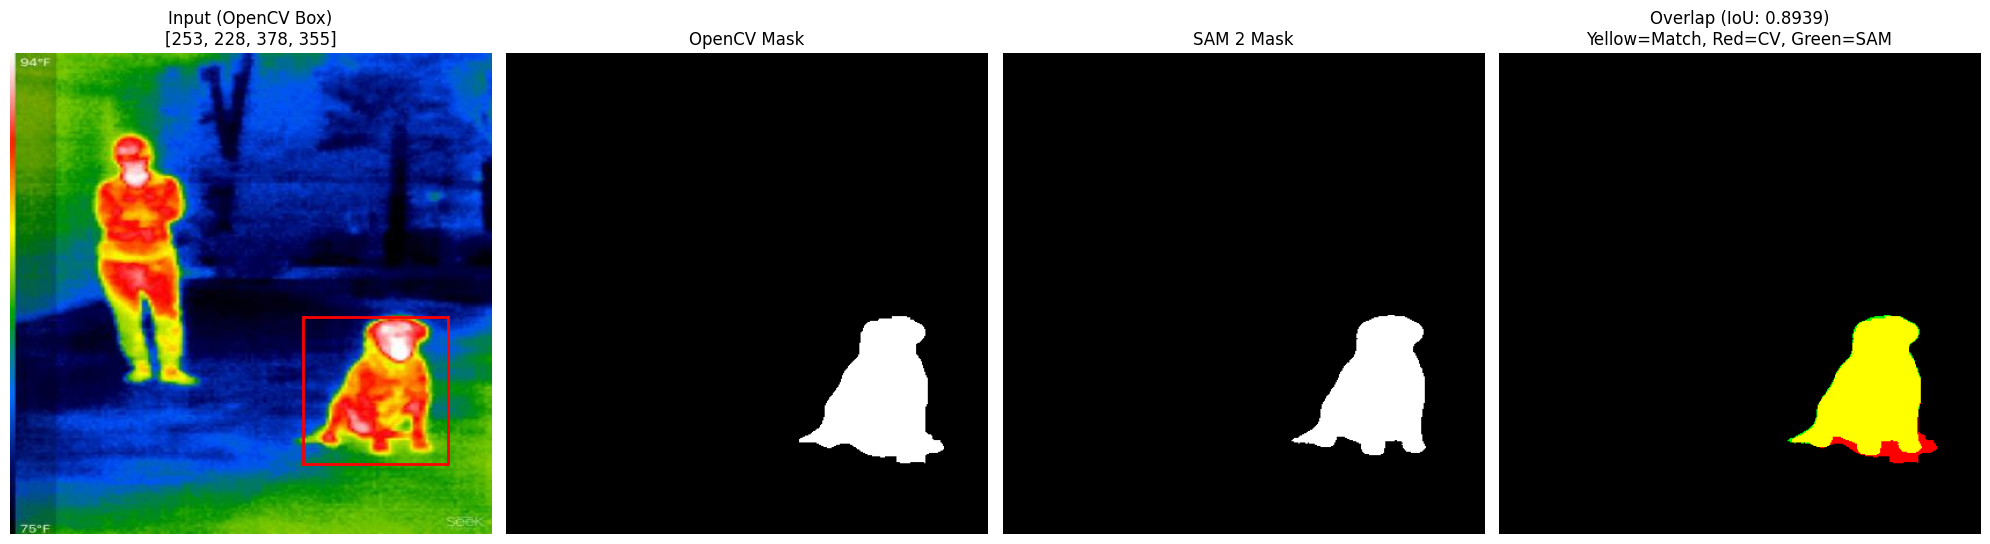

In [3]:
import cv2
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# --- CONFIGURATION ---
URL = "https://transform.roboflow.com/Ly2DeBzbwsemGd2ReHk4BFxy8683/34c0c756031f3cf84c3d52d06431f79e/transformed.jpg"
SAM2_CHECKPOINT = "sam2_hiera_tiny.pt"
SAM2_CONFIG = "sam2_hiera_t.yaml"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running on device: {DEVICE}")

# --- 1. LOAD IMAGE ---
response = requests.get(URL)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
img_array = np.array(img_pil)
# OpenCV uses BGR
image_bgr = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

# --- 2. YOUR OPENCV IMPLEMENTATION ---
def get_opencv_mask_and_bbox(img_bgr):
    """
    Returns the binary mask and the bounding box (x, y, x2, y2)
    of the largest valid contour found.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Contrast adjustment
    alpha = 1.5
    beta = 0
    adjusted = cv2.convertScaleAbs(gray, alpha=alpha, beta=beta)

    # Blur
    blurred = cv2.medianBlur(adjusted, 5)

    # Threshold
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)

    # Morphology
    kernel = np.ones((5,5), np.uint8)
    refined = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Contours
    contours, _ = cv2.findContours(refined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    final_mask = np.zeros_like(gray)
    best_box = None
    max_area = 0

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        aspect_ratio = float(w)/h

        # Your filters
        if x < 5 and y < 5: continue
        if 1000 < area < 50000:
            if 0.5 < aspect_ratio < 2.0:
                # Keep the largest valid contour for comparison
                if area > max_area:
                    max_area = area
                    best_box = [x, y, x + w, y + h] # Format for SAM: x1, y1, x2, y2

                    # Draw filled contour on mask
                    final_mask = np.zeros_like(gray) # Reset
                    cv2.drawContours(final_mask, [cnt], -1, 255, -1)

    return final_mask, best_box

print("Running OpenCV segmentation...")
cv_mask, bbox = get_opencv_mask_and_bbox(image_bgr)

if bbox is None:
    print("Error: OpenCV script did not find a valid object.")
    exit()

# --- 3. SAM 2 IMPLEMENTATION ---
print("Loading SAM 2...")
# Note: You need the model config file in your path or passed explicitly
sam2_model = build_sam2(SAM2_CONFIG, SAM2_CHECKPOINT, device=DEVICE)
predictor = SAM2ImagePredictor(sam2_model)

print("Running SAM 2 inference...")
predictor.set_image(img_array) # SAM uses RGB

# We use the bbox from OpenCV as the "prompt" for SAM 2
# This asks SAM: "Look inside this box and give me the exact object boundary"
input_box = np.array(bbox)

masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=input_box[None, :],
    multimask_output=False,
)

sam_mask = (masks[0] * 255).astype(np.uint8)

# --- 4. COMPARISON & METRICS (IoU) ---
def calculate_iou(mask1, mask2):
    # Flatten and ensure boolean
    m1 = mask1 > 0
    m2 = mask2 > 0

    intersection = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()

    if union == 0: return 0
    return intersection / union

iou_score = calculate_iou(cv_mask, sam_mask)
print(f"Intersection over Union (IoU) Score: {iou_score:.4f}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(20, 6))

# 1. Original with Box
plt.subplot(1, 4, 1)
plt.title(f"Input (OpenCV Box)\n{bbox}")
plt.imshow(img_array)
if bbox is not None:
    x1, y1, x2, y2 = bbox
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
    plt.gca().add_patch(rect)
plt.axis('off')

# 2. OpenCV Result
plt.subplot(1, 4, 2)
plt.title("OpenCV Mask")
plt.imshow(cv_mask, cmap='gray')
plt.axis('off')

# 3. SAM 2 Result
plt.subplot(1, 4, 3)
plt.title("SAM 2 Mask")
plt.imshow(sam_mask, cmap='gray')
plt.axis('off')

# 4. Difference / Overlap
# Create an empty black image
combined_vis = np.zeros((img_array.shape[0], img_array.shape[1], 3), dtype=np.uint8)

# Assign OpenCV mask (0-255) directly to the RED channel (channel 0)
combined_vis[:, :, 0] = cv_mask

# Assign SAM mask (0-255) directly to the GREEN channel (channel 1)
combined_vis[:, :, 1] = sam_mask

# Result Logic:
# - Pixel is Red (255, 0, 0) -> OpenCV only
# - Pixel is Green (0, 255, 0) -> SAM only
# - Pixel is Yellow (255, 255, 0) -> Both (Overlap)

plt.subplot(1, 4, 4)
plt.title(f"Overlap (IoU: {iou_score:.4f})\nYellow=Match, Red=CV, Green=SAM")
plt.imshow(combined_vis)
plt.axis('off')

plt.tight_layout()
plt.show()